In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import matplotlib.pylab as plt

In [29]:
X = 6 * np.random.rand(200, 1) - 3
Y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

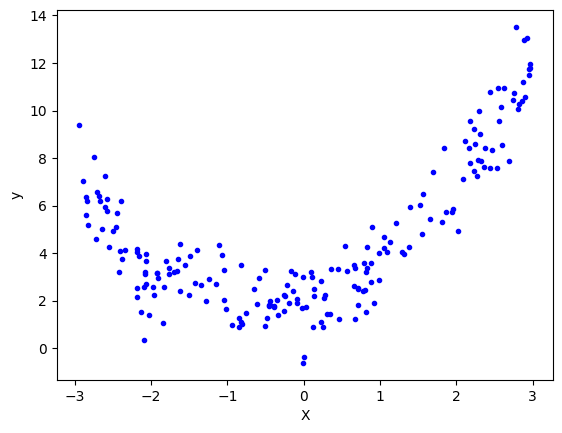

In [30]:
plt.plot(X, Y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.2, random_state=42)
X_train

array([[ 2.90000064],
       [-1.69780894],
       [ 2.59600125],
       [-0.50436522],
       [-0.85199217],
       [-2.38579446],
       [-0.386014  ],
       [ 1.96134532],
       [ 0.536374  ],
       [ 2.11730893],
       [-1.96181991],
       [ 2.44575653],
       [ 0.34886956],
       [-0.4483892 ],
       [ 0.23089857],
       [ 2.8241465 ],
       [-2.40702212],
       [ 2.18489307],
       [-2.15474692],
       [-1.76994795],
       [ 1.28973405],
       [ 1.54713285],
       [-1.0512284 ],
       [-1.84531309],
       [-2.60232018],
       [-2.85844048],
       [ 2.08640542],
       [-0.25960609],
       [ 2.86981994],
       [ 1.52475462],
       [-1.91832186],
       [ 2.78042975],
       [ 0.45733171],
       [ 1.05261863],
       [ 0.71716398],
       [-0.82608228],
       [-0.81941575],
       [-1.54976623],
       [ 0.87785985],
       [-2.72679295]])

In [32]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred = lr.predict(X_test)
score = r2_score(Y_test, y_pred)
print(score)

0.2443034517626611


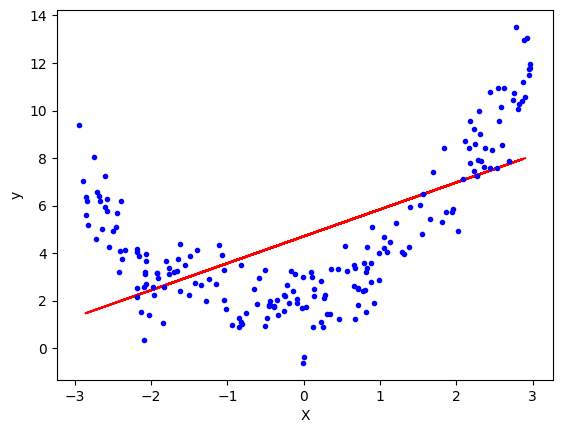

In [34]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, Y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Applying Polynomial Regression

In [35]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [36]:
lr = LinearRegression()
lr.fit(X_train_poly, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
y_pred_poly = lr.predict(X_test_poly)
poly_score = r2_score(Y_test, y_pred_poly)
print(poly_score)

0.8642998898225227


In [38]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

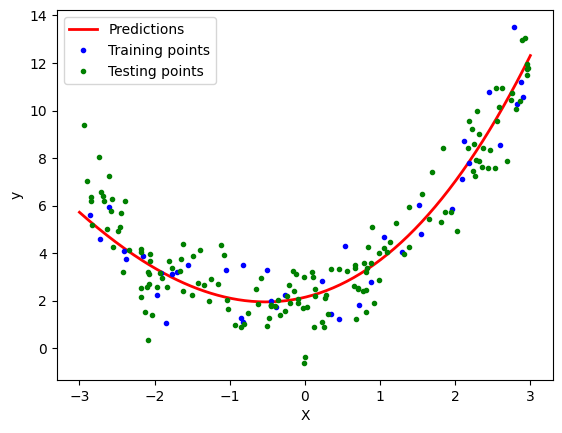

In [39]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, Y_train, "b.",label='Training points')
plt.plot(X_test, Y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()